# Loading Required Librarys

In [1]:
import matplotlib.pyplot as plt # visualization
import numpy as np
import pandas as pd
import random
import seaborn as sns # visualization
from statsmodels.graphics.gofplots import qqplot # visualization
from sklearn.impute import SimpleImputer
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics
import warnings
warnings.filterwarnings('ignore')

# just to jupyter notebook be capable of execute matplotlib
%matplotlib inline

from pandas.plotting import register_matplotlib_converters # avoid erros between pandas and matplotlib
register_matplotlib_converters()

# Importing and cleaning our dataset

In [2]:
lr_data = pd.read_excel('C:/Users/PURITY/Documents/Jobs/python project/compactiv.xlsx')
# Process the data using pandas methods
lr_data.head(5)

,lread,lwrite,scall,sread,swrite,fork,exec,rchar,wchar,pgout,...,pgscan,atch,pgin,ppgin,pflt,vflt,runqsz,freemem,freeswap,usr
0,1,0,2147,79,68,0.2,0.2,40671.0,53995.0,0.0,...,0.0,0.0,1.6,2.6,16.00,26.40,CPU_Bound,4670,1730946,95
1,0,0,170,18,21,0.2,0.2,448.0,8385.0,0.0,...,0.0,0.0,0.0,0.0,15.63,16.83,Not_CPU_Bound,7278,1869002,97
2,15,3,2162,159,119,2.0,2.4,NaN,31950.0,0.0,...,0.0,1.2,6.0,9.4,150.20,220.20,Not_CPU_Bound,702,1021237,87
3,0,0,160,12,16,0.2,0.2,NaN,8670.0,0.0,...,0.0,0.0,0.2,0.2,15.60,16.80,Not_CPU_Bound,7248,1863704,98
4,5,1,330,39,38,0.4,0.4,NaN,12185.0,0.0,...,0.0,0.0,1.0,1.2,37.80,47.60,Not_CPU_Bound,633,1760253,90


In [3]:
# Seeing dataset structure
lr_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8192 entries, 0 to 8191
Data columns (total 22 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   lread     8192 non-null   int64  
 1   lwrite    8192 non-null   int64  
 2   scall     8192 non-null   int64  
 3   sread     8192 non-null   int64  
 4   swrite    8192 non-null   int64  
 5   fork      8192 non-null   float64
 6   exec      8192 non-null   float64
 7   rchar     8088 non-null   float64
 8   wchar     8177 non-null   float64
 9   pgout     8192 non-null   float64
 10  ppgout    8192 non-null   float64
 11  pgfree    8192 non-null   float64
 12  pgscan    8192 non-null   float64
 13  atch      8192 non-null   float64
 14  pgin      8192 non-null   float64
 15  ppgin     8192 non-null   float64
 16  pflt      8192 non-null   float64
 17  vflt      8192 non-null   float64
 18  runqsz    8192 non-null   object 
 19  freemem   8192 non-null   int64  
 20  freeswap  8192 non-null   int6

In [74]:
# seeing dataset shape
lr_data.shape

(8192, 22)

In [75]:
# Seeing columns
lr_data.describe()

,lread,lwrite,scall,sread,swrite,fork,exec,rchar,wchar,pgout,...,pgfree,pgscan,atch,pgin,ppgin,pflt,vflt,freemem,freeswap,usr
count,8192.000000,8192.000000,8192.000000,8192.000000,8192.000000,8192.000000,8192.000000,8.088000e+03,8.177000e+03,8192.000000,...,8192.000000,8192.000000,8192.000000,8192.000000,8192.000000,8192.000000,8192.000000,8192.000000,8.192000e+03,8192.000000
mean,19.559692,13.106201,2306.318237,210.479980,150.058228,1.884554,2.791998,1.973857e+05,9.590299e+04,2.285317,...,11.919712,21.526849,1.127505,8.277960,12.388586,109.793799,185.315796,1763.456299,1.328126e+06,83.968872
std,53.353799,29.891726,1633.617322,198.980146,160.478980,2.479493,5.212456,2.398375e+05,1.408417e+05,5.307038,...,32.363520,71.141340,5.708347,13.874978,22.281318,114.419221,191.000603,2482.104511,4.220194e+05,18.401905
min,0.000000,0.000000,109.000000,6.000000,7.000000,0.000000,0.000000,2.780000e+02,1.498000e+03,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.200000,55.000000,2.000000e+00,0.000000
25%,2.000000,0.000000,1012.000000,86.000000,63.000000,0.400000,0.200000,3.409150e+04,2.291600e+04,0.000000,...,0.000000,0.000000,0.000000,0.600000,0.600000,25.000000,45.400000,231.000000,1.042624e+06,81.000000
50%,7.000000,1.000000,2051.500000,166.000000,117.000000,0.800000,1.200000,1.254735e+05,4.661900e+04,0.000000,...,0.000000,0.000000,0.000000,2.800000,3.800000,63.800000,120.400000,579.000000,1.289290e+06,89.000000
75%,20.000000,10.000000,3317.250000,279.000000,185.000000,2.200000,2.800000,2.678288e+05,1.061010e+05,2.400000,...,5.000000,0.000000,0.600000,9.765000,13.800000,159.600000,251.800000,2002.250000,1.730380e+06,94.000000
max,1845.000000,575.000000,12493.000000,5318.000000,5456.000000,20.120000,59.560000,2.526649e+06,1.801623e+06,81.440000,...,523.000000,1237.000000,211.580000,141.200000,292.610000,899.800000,1365.000000,12027.000000,2.243187e+06,99.000000


In [76]:
# Looking for total missing values in each column
lr_data.isna().sum()

lread         0
lwrite        0
scall         0
sread         0
swrite        0
fork          0
exec          0
rchar       104
wchar        15
pgout         0
ppgout        0
pgfree        0
pgscan        0
atch          0
pgin          0
ppgin         0
pflt          0
vflt          0
runqsz        0
freemem       0
freeswap      0
usr           0
dtype: int64

## Dealing with missing values

In [77]:
# Compute the mean of "rchar" and "wchar"
rchar_mean = lr_data['rchar'].mean()
wchar_mean = lr_data['wchar'].mean()

# Replace missing values with the mean
lr_data['rchar'].fillna(rchar_mean, inplace=True)
lr_data['wchar'].fillna(wchar_mean, inplace=True)

In [78]:
# Checking if missing values still exist
lr_data.isna().sum()

lread       0
lwrite      0
scall       0
sread       0
swrite      0
fork        0
exec        0
rchar       0
wchar       0
pgout       0
ppgout      0
pgfree      0
pgscan      0
atch        0
pgin        0
ppgin       0
pflt        0
vflt        0
runqsz      0
freemem     0
freeswap    0
usr         0
dtype: int64

All missing values have been replaced with their variable mean.

## Exploratory Analysis

Now that we already cleaned our data and treated missing values, let's explore our dataset to understand and get insights from it.

First of all let's take a look into our target: 'usr'

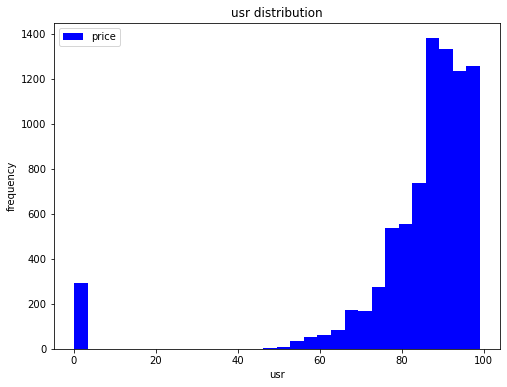

In [79]:
# Plotting a histogram of our feature usr
plt.figure(figsize=(8,6)) # creating the figure
plt.hist(lr_data['usr'] # plotting the histogram
         ,bins=30 # defyning number of bars
         ,label='price' # add legend
        ,color='blue') # defyning the color

plt.xlabel('usr') # add xlabel
plt.ylabel('frequency') # add ylabel
plt.legend()
plt.title('usr distribution');

Clearly our target do not have a normal distribution, let's deal with that later in feature engginering, let's take a look into all numerical distributions

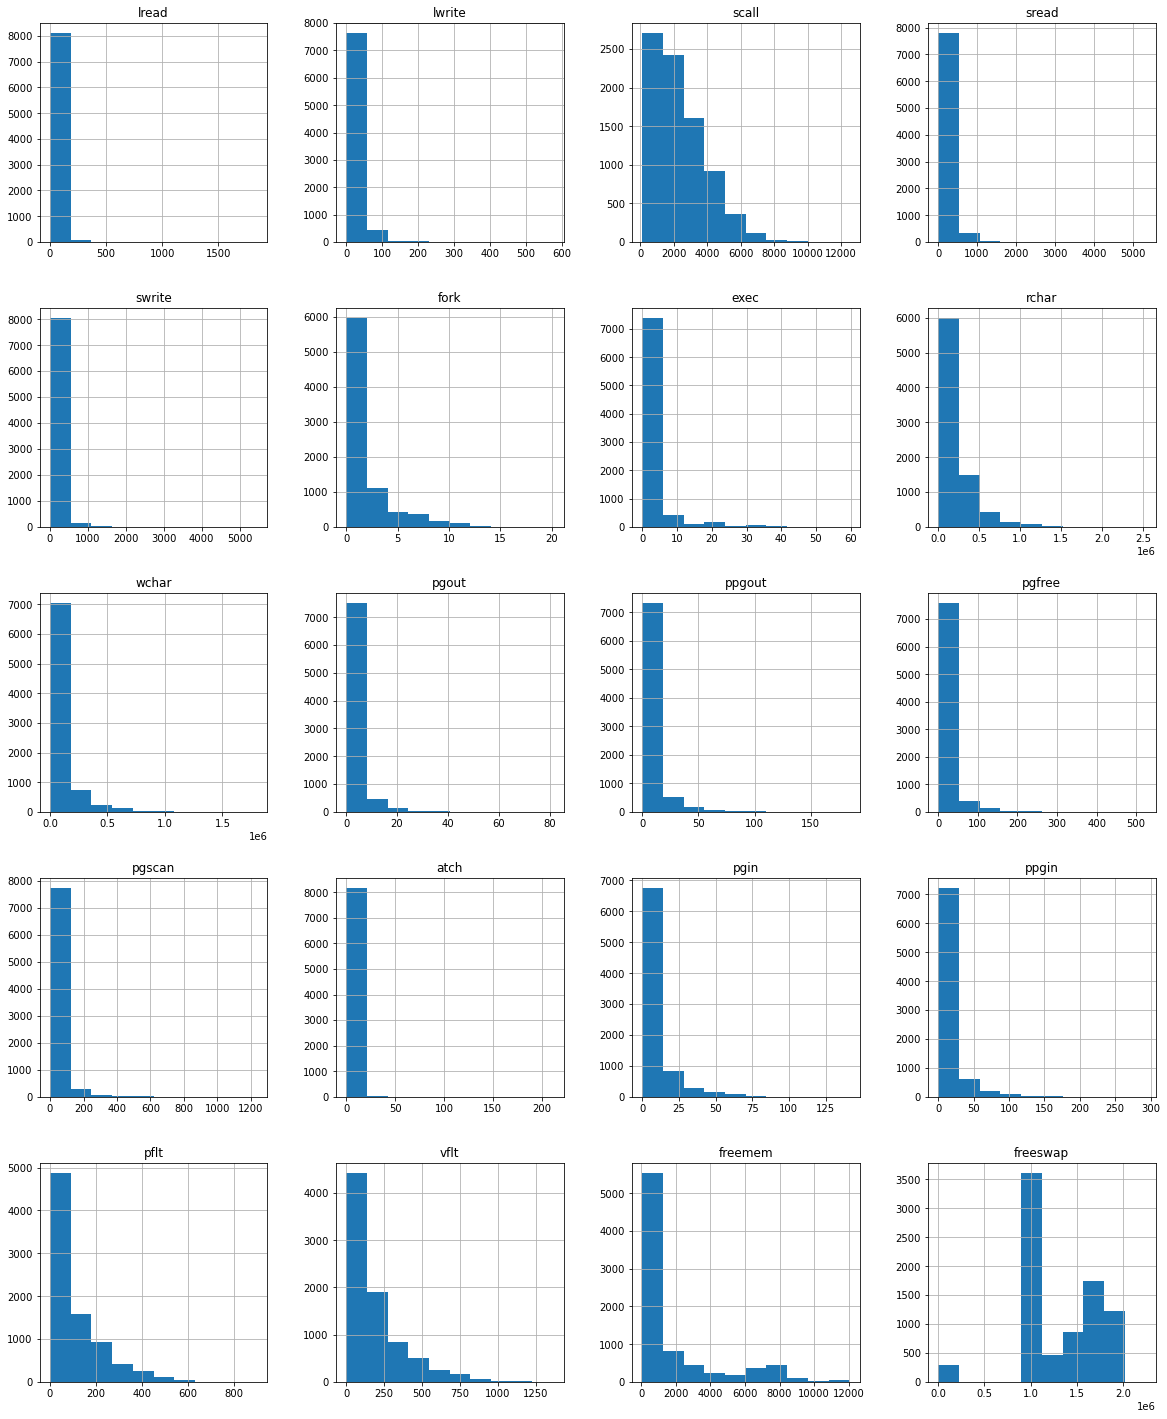

In [80]:
# Saving numerical features
num_var = ['lread', 'lwrite', 'scall', 'sread', 'swrite', 'fork', 'exec',
                  'rchar', 'wchar', 'pgout', 'ppgout', 'pgfree', 'pgscan', 'atch',
                  'pgin', 'ppgin', 'pflt', 'vflt', 'freemem', 'freeswap']

# plotting a histogram for each feature
lr_data[num_var].hist(bins=10
                   , figsize=(20,25)
                   , layout=(5,4));

None of our numerical features have a normal distribution, let's deal with that later in feature engginering, now let's a look in each numerical feature correlation with our target and with each other

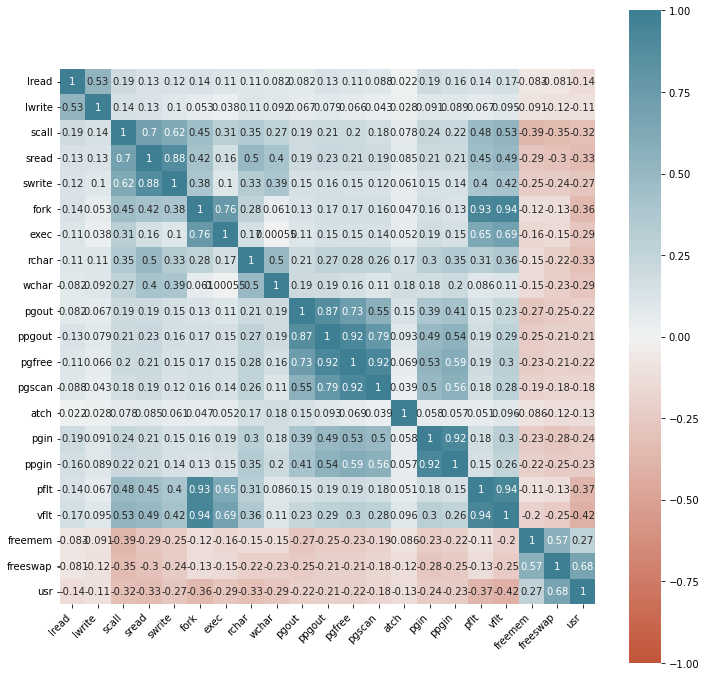

In [81]:
# Numerical variables correlation
corr = lr_data.corr() # creting the correlation matrix

plt.figure(figsize=(12,12)) # creating the and difyning figure size
ax = sns.heatmap( # plotting correlation matrix
    corr,vmin=-1, vmax=1, center=0,
    annot=True,
    cmap=sns.diverging_palette(20, 220, n=200),
    square=True
)
ax.set_xticklabels( # adding axes values
    ax.get_xticklabels(),
    rotation=45,
    horizontalalignment='right'
);

 freeswap is the only variable having a  high correlation with Portion of time (%) that cpus run in user mode, let's make a scatter plot for each of this feature to understand better this relation

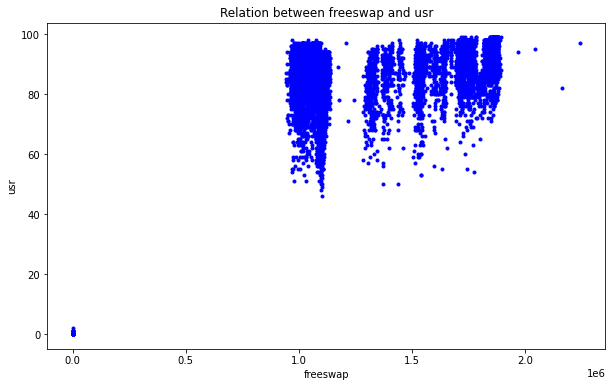

In [82]:
# Plotting a scatter plot of relation between Number of disk blocks available for page swapping and Portion of time
plt.figure(figsize=(10,6)) # creating the figure
plt.plot(lr_data['freeswap'] # plotting
         ,lr_data['usr'],'.'
        ,color='blue')

plt.xlabel('freeswap') # add xlabel
plt.ylabel('usr') # add ylabel
plt.title('Relation between freeswap and usr');

Distribution shows approximately a linear relationship but there are presence of outliers.

####  Let's make a bivariate a analysis of each categorical feature with our target to understand better this features

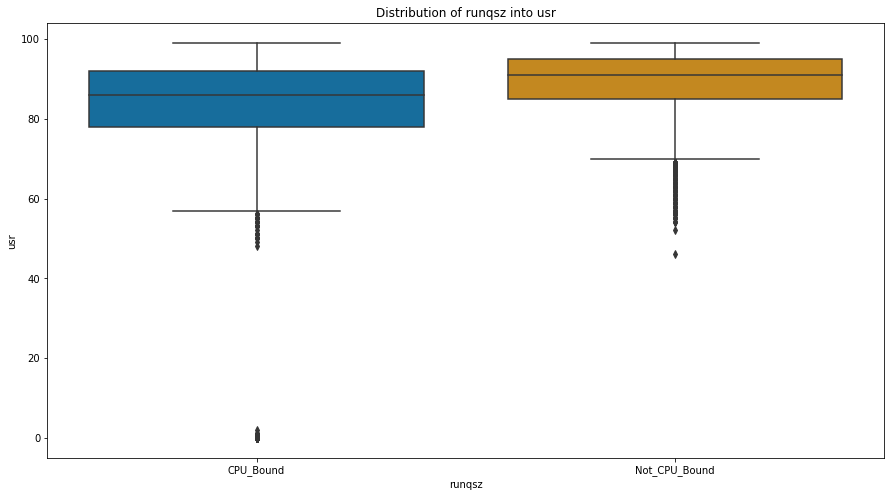

In [85]:
plt.figure(figsize=(15,8))
sns.boxplot(x='runqsz',y='usr',data=lr_data, 
                 palette="colorblind")
plt.title('Distribution of runqsz into usr');

Portion of time to Process run queue size of not bound CPU is slightly higher than that of CPU bound. 
Presence of outliers can be seen in the plots.

## Feature Engineering

### Dealing with outlayers in numeric features

We can create a boxplot for each numerical feature to visualize outlayers and use this boxplots to remove then using Boxplot Interquartile Range(IQR) method.

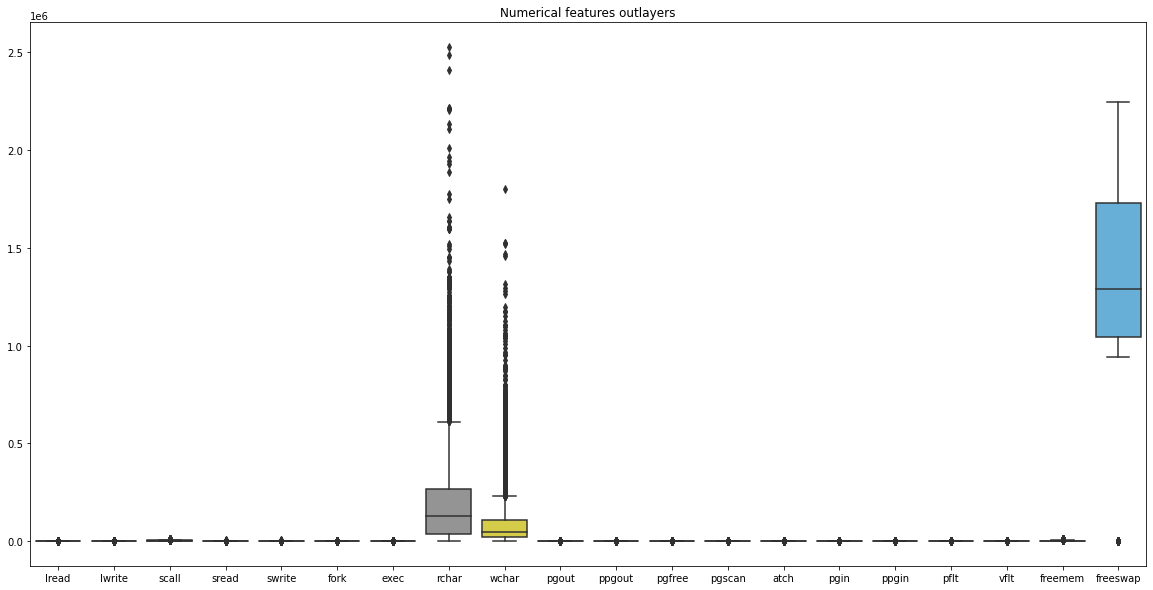

In [86]:
# Plotting boxplots to numeric features
num_var = ['lread', 'lwrite', 'scall', 'sread', 'swrite', 'fork', 'exec',
                  'rchar', 'wchar', 'pgout', 'ppgout', 'pgfree', 'pgscan', 'atch',
                  'pgin', 'ppgin', 'pflt', 'vflt', 'freemem', 'freeswap']
plt.figure(figsize=(20,10))
sns.boxplot(data=lr_data[num_var], 
                 palette="colorblind")
plt.title('Numerical features outlayers');

rchar,wchar and freeswap variable have outliers as shown in the outputs.

In [87]:
# creating a for to replace outlayers using boxplot method
for i in num_var:
    # taking quantiles
    Q1 =  lr_data[i].quantile(0.25)
    Q3 =  lr_data[i].quantile(0.75)
    IQR = Q3 - Q1 # calculating IQR
    lr_data[i] = np.where(lr_data[i]>(Q3+1.5*IQR),(Q3+1.5*IQR),lr_data[i]) # removing outlayers
    lr_data[i] = np.where(lr_data[i]<(Q1-1.5*IQR),(Q1-1.5*IQR),lr_data[i]) # removing outlayers

Now let's verifying if outliers was removed

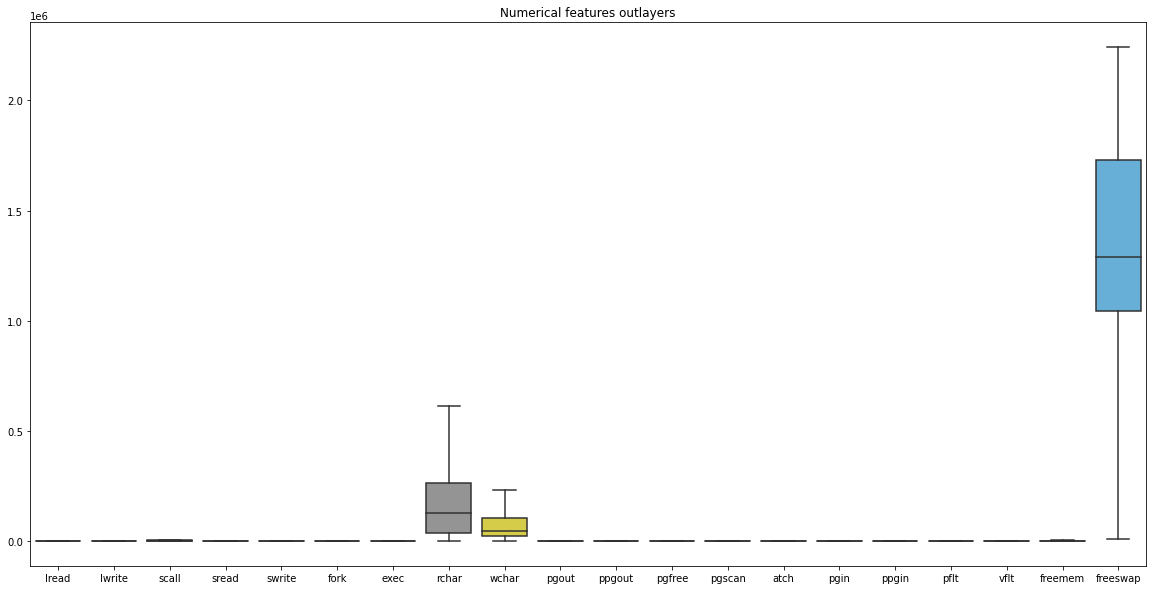

In [88]:
# Plotting boxplots to numeric features
num_var = ['lread', 'lwrite', 'scall', 'sread', 'swrite', 'fork', 'exec',
                  'rchar', 'wchar', 'pgout', 'ppgout', 'pgfree', 'pgscan', 'atch',
                  'pgin', 'ppgin', 'pflt', 'vflt', 'freemem', 'freeswap']
plt.figure(figsize=(20,10))
sns.boxplot(data=lr_data[num_var], 
                 palette="colorblind")
plt.title('Numerical features outlayers');

Dealing with outliers in our target(usr)

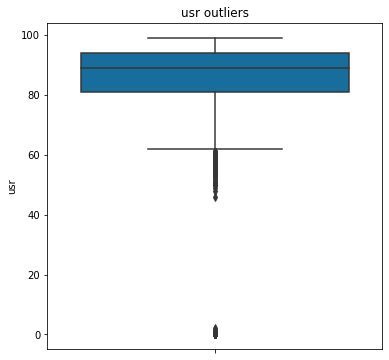

In [89]:
# Plotting a boxplot of our target to visualize outliers
plt.figure(figsize=(6,6))
sns.boxplot(y='usr',data=lr_data, 
                 palette="colorblind")
plt.title('usr outliers');

Here we can see that usr less than 60  are outliers, let's remove then

In [90]:
# Replace outlayers using boxplot method
Q1 = lr_data['usr'].quantile(0.25) # taking Q1
Q3 = lr_data['usr'].quantile(0.75) # taking Q3
IQR = Q3 - Q1 # calculating IQR
lr_data['usr'] = np.where(lr_data['usr']>(Q3+1.5*IQR),(Q3+1.5*IQR),lr_data['usr']) # removing outlayers
lr_data['usr'] = np.where(lr_data['usr']<(Q1-1.5*IQR),(Q1-1.5*IQR),lr_data['usr']) # removing outlayers

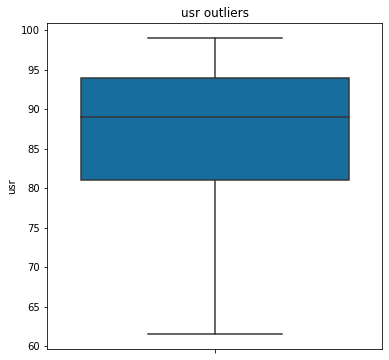

In [91]:
# Visualizing if outliers was removed
plt.figure(figsize=(6,6))
sns.boxplot(y='usr',data=lr_data, 
                 palette="colorblind")
plt.title('usr outliers');

Now its perfect, let's normalize our numerical features using log transformation

### Normalizing our numerical features wigh Log-transformation

First of all let's treat our target 'usr'

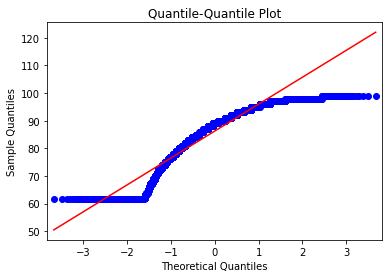

In [45]:
# Quantile-Quantile Plot to virify normal distributions
qqplot(lr_data['usr'], line='s')
plt.title('Quantile-Quantile Plot')
plt.show()

The plot clearly shoes that usr is not a normally distributed. let's use the numpy fuction log1p which applies log(1+x) to all elements of the column 

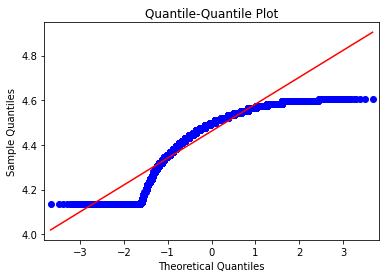

In [46]:
# Log-transformation of the target variable
lr_data['usr'] = np.log1p(lr_data['usr'])

# Quantile-Quantile Plot to virify normal distributions
qqplot(lr_data['usr'], line='s')
plt.title('Quantile-Quantile Plot')
plt.show()

 ## Encoding categorical variable runqsz 

In [50]:
# Converting runqzs into a continuos variable
lr_data['runqsz'][lr_data['runqsz']=='CPU_Bound'] = 1
lr_data['runqsz'][lr_data['runqsz']=='Not_CPU_Bound'] = 0


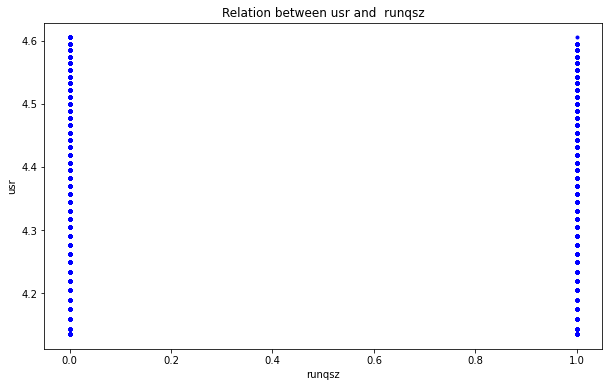

In [51]:
#Plotting a scatter plot of relation between runqsz and usr
plt.figure(figsize=(10,6)) # creating the figure
plt.plot(lr_data['runqsz'] # plotting
         ,lr_data['usr'],'.'
        ,color='blue')

plt.xlabel('runqsz')
plt.ylabel('usr')
plt.title('Relation between usr and  runqsz');

Now let's use log trasformation to solve some problemas with features that are not normal distributed

In [52]:
# taking numerical features to log trasformation
num_var = ['lread', 'lwrite', 'scall', 'sread', 'swrite', 'fork', 'exec',
                  'rchar', 'wchar', 'pgout', 'ppgout', 'pgfree', 'pgscan', 'atch',
                  'pgin', 'ppgin', 'pflt', 'vflt', 'freemem', 'freeswap']

lr_data[num_var] = np.log1p(lr_data[num_var]) # log transformation

Let's visualize the new numerical distributions

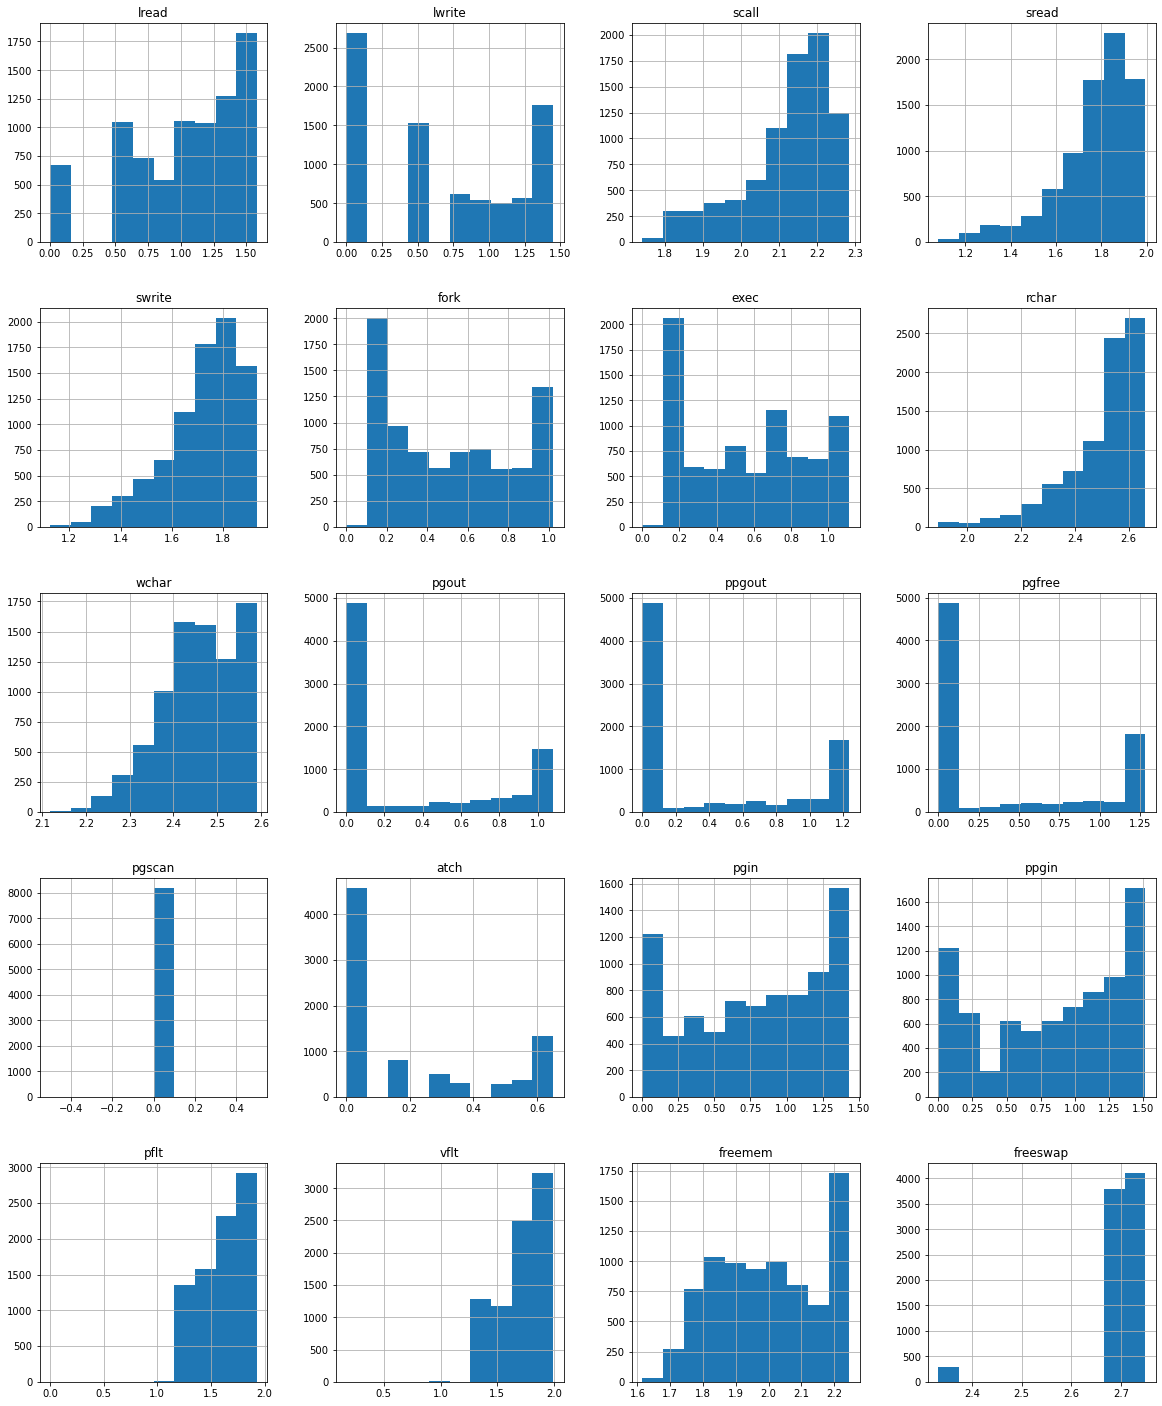

In [53]:
# plotting a histogram for each feature
lr_data[num_var].hist(bins=10
                   , figsize=(20,25)
                   , layout=(5,4));

#### Removing high correlated features

Now let's do a correlation analysis again to remove high correlated features

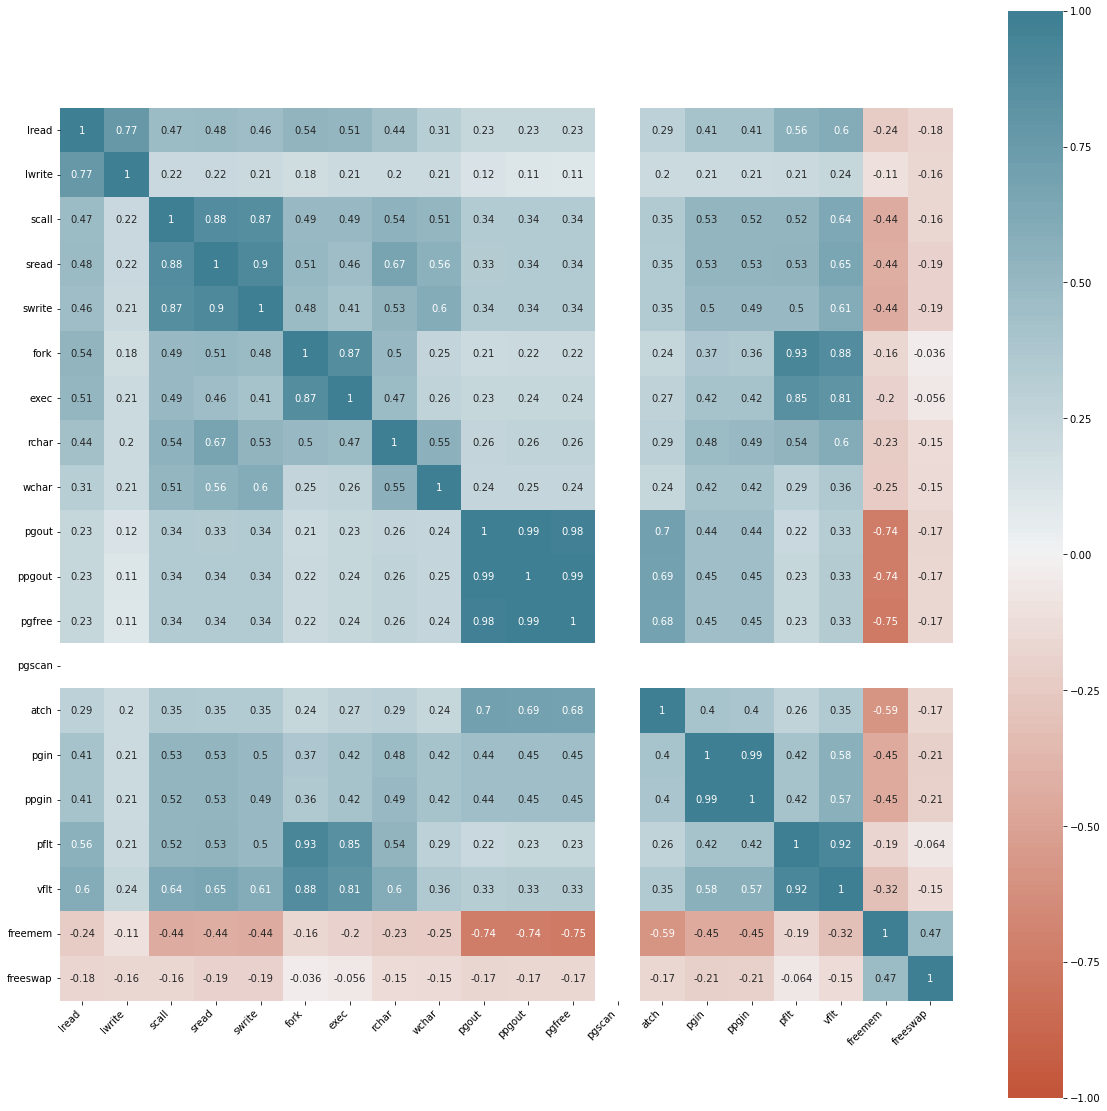

In [54]:
# Numerical variables correlation
lr_data_nousr = lr_data.drop('usr',axis=1) # removing usr column

corr = lr_data_nousr.corr() # creting the correlation matrix

plt.figure(figsize=(20,20)) # creating the and difyning figure size
ax = sns.heatmap( # plotting correlation matrix
    corr,vmin=-1, vmax=1, center=0,
    annot = True,
    cmap=sns.diverging_palette(20, 220, n=200),
    square=True
)
ax.set_xticklabels( # adding axes values
    ax.get_xticklabels(),
    rotation=45,
    horizontalalignment='right'
);

We clearly have some features that are highly correlated with each other, now we have a great number of features, let's select and remove then using a high correlation matrix

In [55]:
# creating the correlation matrix
corr_matrix = lr_data_nousr.corr().abs()

# creating a mask to apply to our correlation matrix and filter high correlations
mask = np.triu(np.ones_like(corr_matrix,dtype=bool))

# replacing low correlations with NA's
tri_df = corr_matrix.mask(mask)

# selecting features to dropp that have correlation with each other above 0.80
to_drop = [c for c in tri_df.columns if any(tri_df[c] > 0.8)]

# dropping high correlated features
lr_data = lr_data.drop(to_drop,axis=1)

Now let's see how this our new correlation matrix but first let's but our target 'price' in the last column

In [56]:
usr = lr_data['usr'] #saving usr
lr_data = lr_data.drop('usr',axis=1) # dropping usr from lr_data dataset
lr_data['usr'] = usr # joing usr into our dataset again

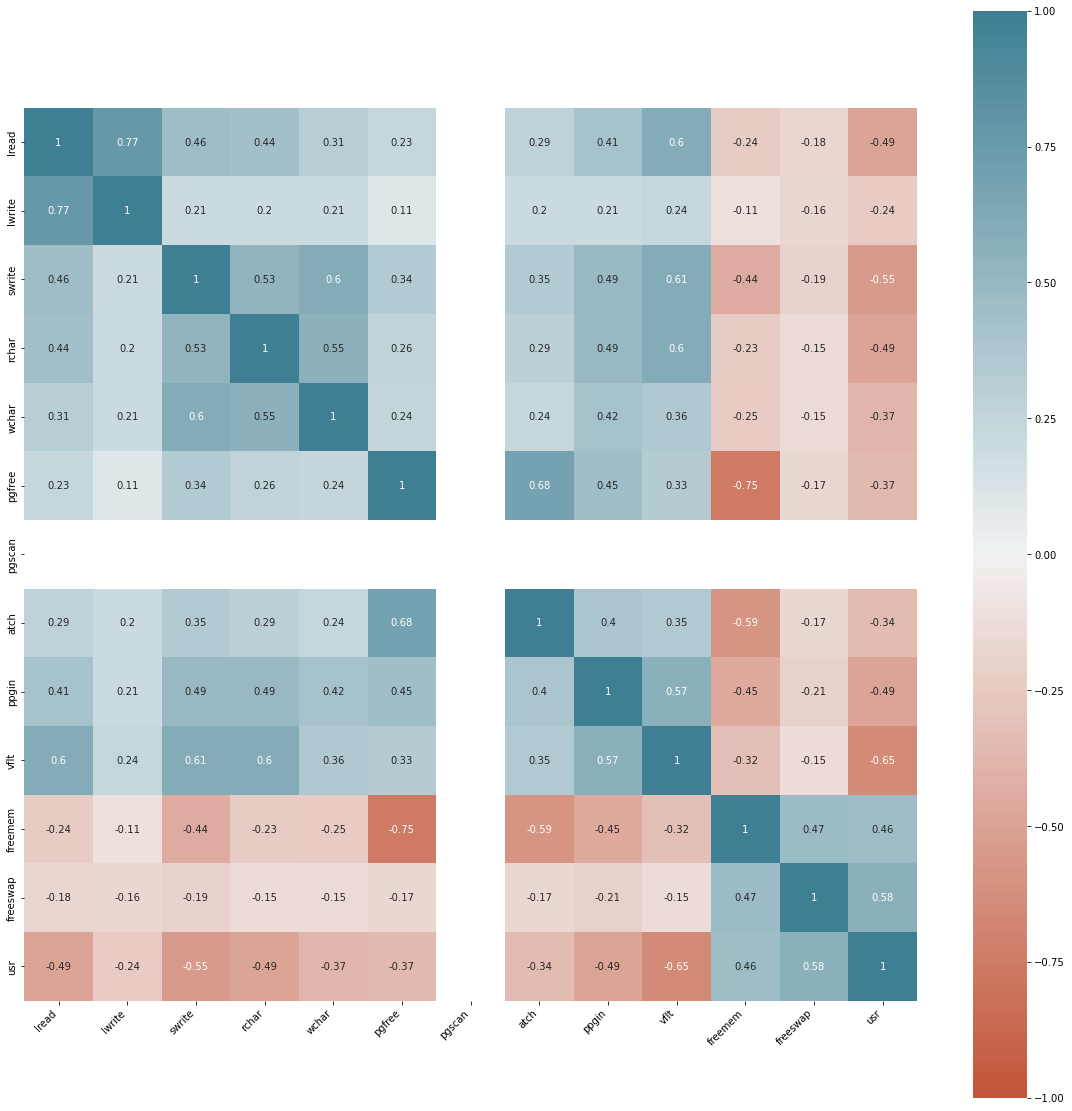

In [57]:
# Numerical variables correlation
corr = lr_data.corr() # creting the correlation matrix

plt.figure(figsize=(20,20)) # creating the and difyning figure size
ax = sns.heatmap( # plotting correlation matrix
    corr,vmin=-1, vmax=1, center=0,
    annot = True,
    cmap=sns.diverging_palette(20, 220, n=200),
    square=True
)
ax.set_xticklabels( # adding axes values
    ax.get_xticklabels(),
    rotation=45,
    horizontalalignment='right'
);

Now that we have removed high correlated features we have less features to process and we this we also can remove chances of overfitting

Now let's put our target in the last column and go to modeling

In [58]:
usr = lr_data['usr'] #saving usr
lr_data = lr_data.drop('usr',axis=1) # dropping usr from lr_data dataset
lr_data['usr'] = usr # joing usr into our dataset again

# Modeling

First of all let's split our dataset into train and test, we need to do this do avoid overfitting in our model and evaluate our model performance, to do this we need to separaty and target from rest of features

In [59]:
#splitting the data with our target into y1 and the rest of data into x1
x1 = lr_data.drop('usr', axis=1)
y1 = lr_data['usr']

In [ ]:
# splitting our dataset into train and target
x_train1, x_test1, y_train1, y_test1 = train_test_split(x1, y1, test_size=0.7,random_state=42) # 70% train and 30% test

## Model Selection

In [92]:
# training the model
regression = LinearRegression()
regression.fit(x_train1, y_train1)

LinearRegression()

In [93]:
LinearRegression(copy_X=True, fit_intercept=True, n_jobs=None, normalize=False)

LinearRegression()

Now let's predict usr in train dataset and latter in test dataset to verify model stabilitty

In [99]:
#predicting on train dataset
y_pred_train1 = regression.predict(x_train1)
y_pred_train1 = np.exp(y_pred_train1)

In [100]:
# predicting on test dataset
y_pred_test1 = regression.predict(x_test1)
y_pred_test1 = np.exp(y_pred_test1)

In [101]:
# removing log transformation from our target
y_train1_exped = np.exp(y_train1)
y_test1_exped = np.exp(y_test1)

Now, to evaluate our model we need to use to matrics: Mean Absolute Error(MAE) and Root Mean Squared Error(RMSE), let's see this metrics in train and test dataset predictions

In [109]:
#Extract the feature names
feature_names = x_train1.columns

# Extract the coefficients
coefficients = regression.coef_

# Print the coefficient with its corresponding feature name
for feature, coef in zip(feature_names, coefficients):
    print(f'Coefficient for {feature}: {coef}')

Coefficient for lread: -0.023544919893249774
Coefficient for lwrite: 0.005917479240118151
Coefficient for swrite: -0.10757415516477796
Coefficient for rchar: -0.011247559284385634
Coefficient for wchar: -0.014900933811558381
Coefficient for pgfree: -0.032411707663898046
Coefficient for pgscan: -4.649058915617843e-16
Coefficient for atch: 0.011968950425717712
Coefficient for ppgin: -0.0027959574684815885
Coefficient for vflt: -0.2515375980013183
Coefficient for runqsz: -0.008001228025850625
Coefficient for freemem: -0.07851793609570934
Coefficient for freeswap: 0.8305135774982234


In [106]:
intercept = regression.intercept_
print(f'Intercept: {intercept}')

Intercept: 3.094096180604218


In [105]:
# model quality metrics in test dataset prediction
print('Mean Absolute Error:', metrics.mean_absolute_error(y_test1_exped, y_pred_test1))
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_test1_exped, y_pred_test1)))

Mean Absolute Error: 4.298851067393424
Root Mean Squared Error: 5.45853601052835


They is a slight difference between the two Errors

Now, to evaluate our model we need to use to matrics: Mean Absolute Error(MAE) and Root Mean Squared Error(RMSE), let's see this metrics in train and test dataset predictions

## Evaluating our model with Mae Ratio metrics

Mae Ratio is take the MAE percentage in relation to mean usr of our test dataset, this metrics it's called MAE RATIO, with this metric we can measure how far our predictions was from the mean of our target, the lower our MAE RATIO is, better our model is, the best scenario it's a model with a MAE RATIO with less then 10.

In [69]:
print("The mean usr of our test dataset is: ")
print(y_test1_exped.mean()) # calculating the mean of our usr
print()
print("The MAE percentage in relation to mean usr of our test dataset is: ")
print(round(metrics.mean_absolute_error(y_test1_exped, y_pred_test1)/y_test1_exped.mean()*100,2)) # calculating mae ratio

The mean usr of our test dataset is: 
87.29782040104621

The MAE percentage in relation to mean usr of our test dataset is: 
4.92
